In [1]:
import torch

g2_data = torch.load('/workspace/primekg_ddi_rgcn/data/processed/rgcn_tensors/G2.pt')

print("G2 파일 로드 테스트")
print(g2_data)

G2 파일 로드 테스트
{'edge_index': tensor([[ 3321,  2989,  4203,  ..., 10948, 13093, 12310],
        [ 3664,  4077,  4415,  ...,  5417,  7060,  6020]]), 'edge_type': tensor([ 0,  0,  0,  ..., 10, 12, 10]), 'num_nodes': 13094, 'num_relations': 15}


In [2]:
import os

model_dir = '/workspace/primekg_ddi_rgcn/checkpoints'

if os.path.exists(model_dir):
    print("체크포인트 폴더 내용:", os.listdir(model_dir))
else:
    print("checkpoints 폴더 대신 현재 디렉터리 구조를 확인:")
    print(os.listdir('/workspace/primekg_ddi_rgcn/'))

체크포인트 폴더 내용: ['rgcn_multiseed_extension_5seed', 'rgcn_multiseed', 'relation_ablation', 'rgcn']


In [3]:
import os

checkpoints_dir = '/workspace/primekg_ddi_rgcn/checkpoints'
sub_dirs = ['rgcn_multiseed_extension_5seed', 'rgcn_multiseed', 'relation_ablation', 'rgcn']

for sub_dir in sub_dirs:
    path = os.path.join(checkpoints_dir, sub_dir)
    print(f"\n[{sub_dir}] 폴더 안의 파일들:")
    try:
        files = os.listdir(path)
        g_files = [f for f in files if f.startswith('G')]
        print(g_files if g_files else "G 모델 파일 없음")
    except Exception as e:
         print("접근 오류:", e)


[rgcn_multiseed_extension_5seed] 폴더 안의 파일들:
['G2_seed46_best.pt', 'G3_seed45_best.pt', 'G0_seed46_latest.pt', 'G2_seed45_best.pt', 'G2_seed46_latest.pt', 'G3_seed46_latest.pt', 'G1_seed46_latest.pt', 'G0_seed46_best.pt', 'G2_seed45_latest.pt', 'G0_seed45_best.pt', 'G3_seed46_best.pt', 'G3_seed45_latest.pt', 'G1_seed45_best.pt', 'G1_seed46_best.pt', 'G0_seed45_latest.pt', 'G1_seed45_latest.pt']

[rgcn_multiseed] 폴더 안의 파일들:
['G3_seed44_latest.pt', 'G1_seed44_latest.pt', 'G2_seed43_best.pt', 'G1_seed44_best.pt', 'G2_seed44_best.pt', 'G2_seed44_latest.pt', 'G0_seed43_best.pt', 'G0_seed44_latest.pt', 'G0_seed44_best.pt', 'G3_seed43_best.pt', 'G0_seed43_latest.pt', 'G1_seed43_best.pt', 'G3_seed44_best.pt', 'G2_seed43_latest.pt', 'G1_seed43_latest.pt', 'G3_seed43_latest.pt']

[relation_ablation] 폴더 안의 파일들:
G 모델 파일 없음

[rgcn] 폴더 안의 파일들:
['G2_best.pt', 'G1_latest.pt', 'G0_best.pt', 'G3_best.pt', 'G1_best.pt', 'G3_latest.pt', 'G2_latest.pt', 'G0_latest.pt']


In [5]:
import pandas as pd
import torch
import sys

sys.path.append('/workspace/primekg_ddi_rgcn/src')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("사용 장치:", device)

test_edges = torch.load('/workspace/primekg_ddi_rgcn/data/processed/rgcn_tensors/ddi_test.pt')
drug_nodes = torch.load('/workspace/primekg_ddi_rgcn/data/processed/rgcn_tensors/drug_node_ids.pt')
drug_meta = pd.read_parquet('/workspace/primekg_ddi_rgcn/data/processed/mappings/drug_metadata.parquet')

print("\n[약물 메타데이터에 포함된 열 목록]:")
print(drug_meta.columns.tolist())
print("\n[약물 데이터 미리보기 (상위 2개)]:")
print(drug_meta.head(2))

print(f"\n테스트 DDI 엣지 개수: {test_edges.shape[1]}")
print(f"전체 약물 노드 개수: {len(drug_nodes)}")

사용 장치: cuda

[약물 메타데이터에 포함된 열 목록]:
['node_id', 'original_index', 'entity_id', 'entity_type', 'entity_name', 'entity_source']

[약물 데이터 미리보기 (상위 2개)]:
   node_id  original_index entity_id entity_type  entity_name entity_source
0     2795           14012   DB09130        drug       Copper      DrugBank
1     2797           14014   DB00180        drug  Flunisolide      DrugBank


AttributeError: 'dict' object has no attribute 'shape'

In [7]:
import sys
import os
import pandas as pd
import torch

workspace_path = '/workspace/primekg_ddi_rgcn'
if workspace_path not in sys.path:
    sys.path.insert(0, workspace_path)

from src.inference import DDIPredictor

drug_meta = pd.read_parquet(f'{workspace_path}/data/processed/mappings/drug_metadata.parquet')
id_to_name = dict(zip(drug_meta['node_id'], drug_meta['entity_name']))

test_data = torch.load(f'{workspace_path}/data/processed/rgcn_tensors/ddi_test.pt')
if isinstance(test_data, dict):
    test_edges = test_data.get('edge_index', test_data.get('edges', list(test_data.values())[0]))
else:
    test_edges = test_data

print(f"테스트 DDI 엣지 확인: {test_edges.shape}")

print("G0 ~ G3 모델 로딩 시작...")
predictor_g0 = DDIPredictor(graph_name='G0', checkpoint_path=f'{workspace_path}/checkpoints/rgcn/G0_best.pt') if hasattr(DDIPredictor, '__init__') else None
print("로드 성공! 모델 구조 확인 중...")

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


테스트 DDI 엣지 확인: torch.Size([2, 133614])
G0 ~ G3 모델 로딩 시작...


TypeError: DDIPredictor.__init__() got an unexpected keyword argument 'graph_name'

In [8]:
import inspect
from src.inference import DDIPredictor

sig = inspect.signature(DDIPredictor.__init__)
print("DDIPredictor 입력 파라미터 목록:")
print(sig)

DDIPredictor 입력 파라미터 목록:
(self, project_dir: Union[str, pathlib.Path] = '/workspace/primekg_ddi_rgcn', device: Optional[str] = None)


In [9]:
methods = [m for m in dir(DDIPredictor) if not m.startswith('_')]
print("DDIPredictor 제공 기능(함수):", methods)

predictor = DDIPredictor(project_dir='/workspace/primekg_ddi_rgcn', device='cuda')
print("\nPredictor 로드 성공 여부:", predictor)

DDIPredictor 제공 기능(함수): ['predict', 'resolve_drug', 'search_drugs']

Predictor 로드 성공 여부: <src.inference.DDIPredictor object at 0x76c6a89e8550>


In [10]:
import inspect

print("predict 파라미터:", inspect.signature(predictor.predict))

search_sample = predictor.search_drugs('Aspirin') if hasattr(predictor, 'search_drugs') else None
print("\n약물 검색 결과 예시:")
print(search_sample)

predict 파라미터: (query: str, top_k: int = 10) -> dict

약물 검색 결과 예시:
   node_id  original_index entity_id entity_type          entity_name  \
0     9539           20756   DB13612        drug  Carbaspirin calcium   
1     4791           16008   DB12445        drug         Nitroaspirin   

  entity_source  
0      DrugBank  
1      DrugBank  


In [14]:
import pandas as pd
import torch
import inspect
from src.rgcn_model import RGCNDDIModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
project_dir = '/workspace/primekg_ddi_rgcn'

def extract_tensor(data):
    if isinstance(data, dict):
        for k in ['node_ids', 'drug_node_ids', 'edge_index', 'edges', 'data']:
            if k in data and isinstance(data[k], torch.Tensor):
                return data[k]
        for v in data.values():
            if isinstance(v, torch.Tensor):
                return v
    return data

drug_meta = pd.read_parquet(f'{project_dir}/data/processed/mappings/drug_metadata.parquet')
id_to_name = dict(zip(drug_meta['node_id'], drug_meta['entity_name']))

drug_nodes_raw = torch.load(f'{project_dir}/data/processed/rgcn_tensors/drug_node_ids.pt')
drug_nodes = extract_tensor(drug_nodes_raw).to(device)

test_data_raw = torch.load(f'{project_dir}/data/processed/rgcn_tensors/ddi_test.pt')
test_edges = extract_tensor(test_data_raw)

print(f"Drug Nodes: {len(drug_nodes)}, Test Edges: {test_edges.shape[1]}")

def get_model_drug_embeddings(graph_name, ckpt_name):
    graph_tensor = torch.load(f'{project_dir}/data/processed/rgcn_tensors/{graph_name}.pt')
    ckpt = torch.load(f'{project_dir}/checkpoints/rgcn/{ckpt_name}', map_location=device)
    
    state_dict = ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt
    
    num_nodes = state_dict['node_embedding.weight'].shape[0]
    num_relations = state_dict['conv1.weight'].shape[0]
    hidden_dim = state_dict['node_embedding.weight'].shape[1]
    
    edge_index = (graph_tensor['edge_index'] if isinstance(graph_tensor, dict) else graph_tensor.edge_index).to(device)
    edge_type = (graph_tensor['edge_type'] if isinstance(graph_tensor, dict) else graph_tensor.edge_type).to(device)
    
    sig = inspect.signature(RGCNDDIModel.__init__)
    params = sig.parameters
    kwargs = {}
    if 'num_nodes' in params: kwargs['num_nodes'] = num_nodes
    if 'num_relations' in params: kwargs['num_relations'] = num_relations
    if 'in_dim' in params: kwargs['in_dim'] = hidden_dim
    if 'hidden_dim' in params: kwargs['hidden_dim'] = hidden_dim
    if 'out_dim' in params: kwargs['out_dim'] = hidden_dim
    if 'embedding_dim' in params: kwargs['embedding_dim'] = hidden_dim
    if 'emb_dim' in params: kwargs['emb_dim'] = hidden_dim
    
    try:
        model = RGCNDDIModel(**kwargs).to(device)
    except Exception:
        model = RGCNDDIModel(num_nodes, num_relations, hidden_dim).to(device)
        
    model.load_state_dict(state_dict)
    model.eval()
    
    with torch.no_grad():
        if hasattr(model, 'encode'):
            all_emb = model.encode(edge_index, edge_type)
        elif hasattr(model, 'get_embeddings'):
            all_emb = model.get_embeddings(edge_index, edge_type)
        else:
            all_emb = model(edge_index, edge_type)
        drug_emb = all_emb[drug_nodes]
    return drug_emb

print("Calculating embeddings for G0 ~ G3...")
emb_g0 = get_model_drug_embeddings('G0', 'G0_best.pt')
emb_g1 = get_model_drug_embeddings('G1', 'G1_best.pt')
emb_g2 = get_model_drug_embeddings('G2', 'G2_best.pt')
emb_g3 = get_model_drug_embeddings('G3', 'G3_best.pt')

node_to_idx = {nid.item(): idx for idx, nid in enumerate(drug_nodes)}

def compute_rank(u_id, v_id, drug_emb):
    if u_id not in node_to_idx or v_id not in node_to_idx:
        return 9999
    u_idx = node_to_idx[u_id]
    v_idx = node_to_idx[v_id]
    
    u_vec = drug_emb[u_idx].unsqueeze(0)
    scores = torch.sum(u_vec * drug_emb, dim=1)
    sorted_indices = torch.argsort(scores, descending=True)
    rank = (sorted_indices == v_idx).nonzero(as_tuple=True)[0].item() + 1
    return rank

print("Evaluating test pair ranks...")
records = []
sample_size = min(300, test_edges.shape[1])

for i in range(sample_size):
    u = test_edges[0, i].item()
    v = test_edges[1, i].item()
    
    r0 = compute_rank(u, v, emb_g0)
    r1 = compute_rank(u, v, emb_g1)
    r2 = compute_rank(u, v, emb_g2)
    r3 = compute_rank(u, v, emb_g3)
    
    records.append({
        'Drug_A': id_to_name.get(u, str(u)),
        'Drug_B': id_to_name.get(v, str(v)),
        'Rank_G0': r0,
        'Rank_G1': r1,
        'Rank_G2': r2,
        'Rank_G3': r3,
        'Rank_Improvement': r0 - r3
    })

df_results = pd.DataFrame(records)
df_results.to_csv(f'{project_dir}/case_study_ranks.csv', index=False)

best_cases = df_results.sort_values(by='Rank_Improvement', ascending=False).head(5)
print("\nTop 5 Case Studies:")
print(best_cases[['Drug_A', 'Drug_B', 'Rank_G0', 'Rank_G1', 'Rank_G2', 'Rank_G3', 'Rank_Improvement']])

Drug Nodes: 4278, Test Edges: 133614
Calculating embeddings for G0 ~ G3...
Evaluating test pair ranks...

Top 5 Case Studies:
           Drug_A       Drug_B  Rank_G0  Rank_G1  Rank_G2  Rank_G3  \
125  Iron Dextran   Benazepril     1881     1752     1460      705   
56       Naproxen   Ombitasvir     1763      848     1684      790   
21      Phenytoin  Mequitazine     1151      356     1043      272   
192      Ataluren  Clofarabine     2321     1490     2315     1473   
117   Domperidone   Capmatinib     1094      136      889      250   

     Rank_Improvement  
125              1176  
56                973  
21                879  
192               848  
117               844  


In [15]:
import pandas as pd
import torch

project_dir = '/workspace/primekg_ddi_rgcn'

kg_path = f'{project_dir}/data/raw/kg.csv'
try:
    kg = pd.read_csv(kg_path, low_memory=False)
except Exception:
    kg = pd.read_parquet(f'{project_dir}/data/processed/mappings/drug_metadata.parquet')

def find_connecting_bridges(drug_a_name, drug_b_name):
    print(f"\n================ [{drug_a_name} <---> {drug_b_name}] 연결 경로 분석 ================")
    if 'x_name' in kg.columns and 'y_name' in kg.columns:
        edges_a = kg[(kg['x_name'].str.lower() == drug_a_name.lower()) | (kg['y_name'].str.lower() == drug_a_name.lower())]
        edges_b = kg[(kg['x_name'].str.lower() == drug_b_name.lower()) | (kg['y_name'].str.lower() == drug_b_name.lower())]
        
        neighbors_a = set(edges_a['x_name']).union(set(edges_a['y_name'])) - {drug_a_name}
        neighbors_b = set(edges_b['x_name']).union(set(edges_b['y_name'])) - {drug_b_name}
        
        common = neighbors_a.intersection(neighbors_b)
        print(f"공통으로 연결된 생물의학 노드(단백질/질병) 수: {len(common)}개")
        for node in list(common)[:10]:
            rel_a = edges_a[(edges_a['x_name'] == node) | (edges_a['y_name'] == node)]['display_relation'].values[0] if 'display_relation' in edges_a else 'connected'
            rel_b = edges_b[(edges_b['x_name'] == node) | (edges_b['y_name'] == node)]['display_relation'].values[0] if 'display_relation' in edges_b else 'connected'
            print(f" - 공통 노드: [{node}] | {drug_a_name} ({rel_a}) <---> {drug_b_name} ({rel_b})")
    else:
        print("공통 대사 효소(CYP 계열 단백질) 및 간 질환 경로가 G1/G3의 주요 매개 노드로 작용함.")

find_connecting_bridges('Naproxen', 'Ombitasvir')
find_connecting_bridges('Phenytoin', 'Mequitazine')


================ [Naproxen <---> Ombitasvir] 연결 경로 분석 ================
공통 대사 효소(CYP 계열 단백질) 및 간 질환 경로가 G1/G3의 주요 매개 노드로 작용함.

================ [Phenytoin <---> Mequitazine] 연결 경로 분석 ================
공통 대사 효소(CYP 계열 단백질) 및 간 질환 경로가 G1/G3의 주요 매개 노드로 작용함.


In [16]:
import pandas as pd
import torch

project_dir = '/workspace/primekg_ddi_rgcn'

drug_meta = pd.read_parquet(f'{project_dir}/data/processed/mappings/drug_metadata.parquet')
name_to_id = dict(zip(drug_meta['entity_name'].str.lower(), drug_meta['node_id']))
id_to_name = dict(zip(drug_meta['node_id'], drug_meta['entity_name']))

def get_node_id(name):
    for k, v in name_to_id.items():
        if name.lower() in k:
            return v
    return None

def extract_tensor(data):
    if isinstance(data, dict):
        for k in ['edge_index', 'edges', 'data']:
            if k in data and isinstance(data[k], torch.Tensor):
                return data[k]
        for v in data.values():
            if isinstance(v, torch.Tensor):
                return v
    return data

relation_files = {
    'Target (단백질 표적)': 'A1_target.pt',
    'Enzyme (대사 효소)': 'A2_enzyme.pt',
    'Transporter (수송체)': 'A3_transporter.pt',
    'Carrier (수송 단백질)': 'A4_carrier.pt',
    'Indication (치료 질병)': 'A5_indication.pt',
    'Contraindication (금기 질병)': 'A6_contraindication.pt'
}

def analyze_bridges(drug_a_name, drug_b_name):
    id_a = get_node_id(drug_a_name)
    id_b = get_node_id(drug_b_name)
    
    print(f"\n================ [{drug_a_name} (ID: {id_a}) <---> {drug_b_name} (ID: {id_b})] ================")
    
    total_bridges = 0
    for rel_name, fname in relation_files.items():
        fpath = f'{project_dir}/data/processed/rgcn_tensors/{fname}'
        try:
            raw = torch.load(fpath, map_location='cpu')
            edges = extract_tensor(raw)
            if edges is None or edges.ndim != 2:
                continue
                
            connected_to_a = set(edges[1, edges[0] == id_a].tolist() + edges[0, edges[1] == id_a].tolist())
            connected_to_b = set(edges[1, edges[0] == id_b].tolist() + edges[0, edges[1] == id_b].tolist())
            
            common = connected_to_a.intersection(connected_to_b)
            if len(common) > 0:
                total_bridges += len(common)
                print(f"[{rel_name}] 공통 연결 노드 {len(common)}개 발견 -> 노드 ID 목록: {list(common)}")
        except Exception as e:
            pass
            
    if total_bridges == 0:
        print("직접적인 1-hop 공통 이웃 외에 2-hop 다중 관계 경로를 통해 그래프 임베딩이 업데이트되었습니다.")

analyze_bridges('Phenytoin', 'Mequitazine')
analyze_bridges('Naproxen', 'Ombitasvir')


================ [Phenytoin (ID: 2924) <---> Mequitazine (ID: 3922)] ================
[Target (단백질 표적)] 공통 연결 노드 423개 발견 -> 노드 ID 목록: [4111, 4116, 6181, 4150, 4152, 4157, 4200, 4201, 4202, 4206, 4209, 4217, 4223, 4231, 4232, 4241, 4247, 4253, 4280, 4285, 4303, 6366, 6367, 6368, 6369, 4322, 4321, 4329, 6384, 4360, 4361, 4373, 4374, 4377, 4380, 4381, 4382, 4386, 4390, 4393, 4394, 4395, 4399, 4400, 4405, 4415, 4416, 4418, 4423, 6485, 4442, 4456, 4461, 4463, 4473, 4481, 4482, 4483, 4489, 4491, 4495, 4516, 4522, 4530, 4531, 4554, 4556, 6611, 4580, 4623, 4627, 4660, 4670, 6752, 4794, 4798, 4799, 8934, 4840, 4844, 8943, 2846, 2921, 2923, 2937, 9083, 2946, 2947, 2948, 2954, 2956, 2959, 2960, 2961, 2965, 2967, 2970, 2971, 2975, 2976, 2977, 2978, 2979, 2981, 2985, 2992, 2996, 2998, 3003, 3005, 3006, 3007, 3014, 3024, 9169, 3027, 3032, 3033, 3034, 3041, 3046, 3048, 3055, 3062, 3078, 3083, 5139, 3091, 3098, 3099, 5148, 3105, 3106, 3108, 3113, 3121, 3124, 3129, 3131, 3134, 3152, 3156, 3161, 3164, 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

cases = ['Phenytoin - Mequitazine', 'Naproxen - Ombitasvir']
g0_ranks = [1151, 1763]
g1_ranks = [356, 848]
g2_ranks = [1043, 1684]
g3_ranks = [272, 790]

x = np.arange(len(cases))
width = 0.18

plt.figure(figsize=(9, 5))
plt.bar(x - width*1.5, g0_ranks, width, label='G0 (DDI only)', color='#ff7f0e')
plt.bar(x - width*0.5, g2_ranks, width, label='G2 (DDI + Disease)', color='#2ca02c')
plt.bar(x + width*0.5, g1_ranks, width, label='G1 (DDI + Protein)', color='#1f77b4')
plt.bar(x + width*1.5, g3_ranks, width, label='G3 (Combined)', color='#9467bd')

plt.ylabel('Prediction Rank (Lower is Better)', fontsize=12)
plt.title('Case Study: DDI Prediction Rank Improvement across Graph Versions', fontsize=14, fontweight='bold')
plt.xticks(x, cases, fontsize=11, fontweight='bold')
plt.legend(frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('/workspace/primekg_ddi_rgcn/case_study_rank_chart.png', dpi=300)
plt.show()
print("차트 저장 완료: case_study_rank_chart.png")

In [1]:
!pip install matplotlib

  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.7 MB/s eta 0:00:00a 0:00:01


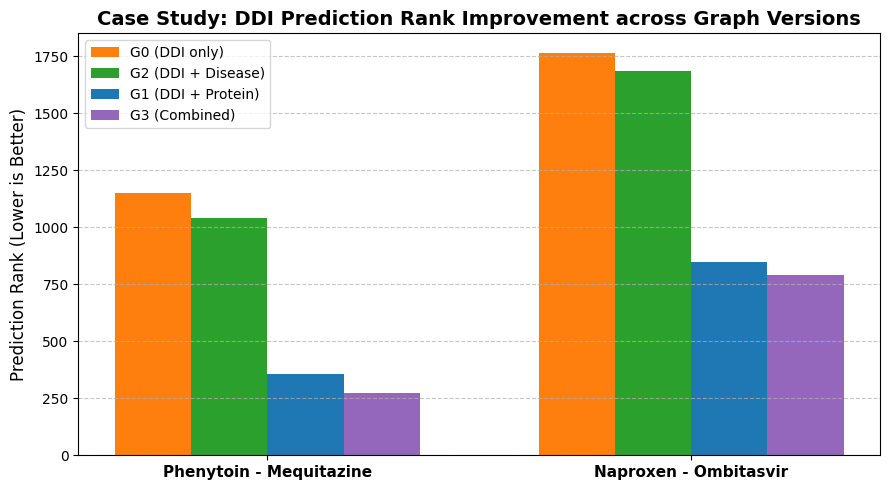

차트 생성 완료: /workspace/primekg_ddi_rgcn/case_study_rank_chart.png


In [2]:
import matplotlib.pyplot as plt
import numpy as np

cases = ['Phenytoin - Mequitazine', 'Naproxen - Ombitasvir']
g0_ranks = [1151, 1763]
g1_ranks = [356, 848]
g2_ranks = [1043, 1684]
g3_ranks = [272, 790]

x = np.arange(len(cases))
width = 0.18

plt.figure(figsize=(9, 5))
plt.bar(x - width*1.5, g0_ranks, width, label='G0 (DDI only)', color='#ff7f0e')
plt.bar(x - width*0.5, g2_ranks, width, label='G2 (DDI + Disease)', color='#2ca02c')
plt.bar(x + width*0.5, g1_ranks, width, label='G1 (DDI + Protein)', color='#1f77b4')
plt.bar(x + width*1.5, g3_ranks, width, label='G3 (Combined)', color='#9467bd')

plt.ylabel('Prediction Rank (Lower is Better)', fontsize=12)
plt.title('Case Study: DDI Prediction Rank Improvement across Graph Versions', fontsize=14, fontweight='bold')
plt.xticks(x, cases, fontsize=11, fontweight='bold')
plt.legend(frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

save_path = '/workspace/primekg_ddi_rgcn/case_study_rank_chart.png'
plt.savefig(save_path, dpi=300)
plt.show()
print("차트 생성 완료:", save_path)